## Data processing code. 

1. Look at data, exploration
2. train dataset, machine learning. 
3. Model is ready!

In [44]:
import sklearn as sk
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix




In [45]:
# Load the dataset 
data = pd.read_csv('ect_remission_data.csv')
# Display the first few rows of the dataset
print(data.head())

# Print column names
print(data.columns)

      Sex AgeGroup MaritalStatus    Education DepressionType  \
0  Female    41-50     Unmarried  10-12 years       Unipolar   
1    Male    31-40       Widowed    ≤10 years       Unipolar   
2    Male    71-80     Unmarried    >12 years       Unipolar   
3    Male    31-40       Married  10-12 years        Bipolar   
4  Female    41-50       Married    ≤10 years       Unipolar   

   PsychoticFeatures  SubstanceUse  PersonalityDisorder  AnxietyDisorder  \
0                  0             0                    0                0   
1                  0             0                    0                0   
2                  0             0                    0                0   
3                  1             0                    0                0   
4                  0             0                    1                1   

  AntidepressantBeforeECT InitialSetting   Coercion  AntidepressantMedication  \
0        0-3 months after     Outpatient  Voluntary                         1

In [46]:
# Split into features and target, remission is what I want to predict
X = data.drop('Remission', axis=1)
y = data['Remission']

# Split into training ,validating and testing sets
X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set size: {X_train.shape}, Testing set size: {X_valtest.shape}")

# Further split validation and testing sets
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=42)
print(f"Validation set size: {X_val.shape}, Testing set size: {X_test.shape}")



Training set size: (1400, 18), Testing set size: (600, 18)
Validation set size: (300, 18), Testing set size: (300, 18)


### Data exploration
Goal is to gain an understanding of the data and its population. 

       PsychoticFeatures  SubstanceUse  PersonalityDisorder  AnxietyDisorder  \
count        1400.000000   1400.000000          1400.000000      1400.000000   
mean            0.453571      0.146429             0.255000         0.517143   
std             0.498018      0.353662             0.436017         0.499885   
min             0.000000      0.000000             0.000000         0.000000   
25%             0.000000      0.000000             0.000000         0.000000   
50%             0.000000      0.000000             0.000000         1.000000   
75%             1.000000      0.000000             1.000000         1.000000   
max             1.000000      1.000000             1.000000         1.000000   

       AntidepressantMedication      Lithium  Lamotrigine    Valproate  \
count               1400.000000  1400.000000  1400.000000  1400.000000   
mean                   0.710000     0.089286     0.042857     0.155000   
std                    0.453924     0.285258     0.202607

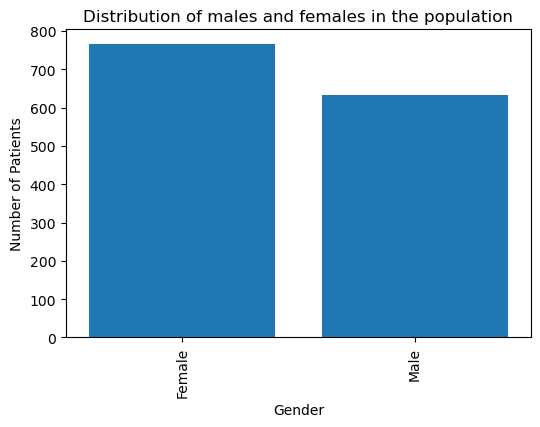

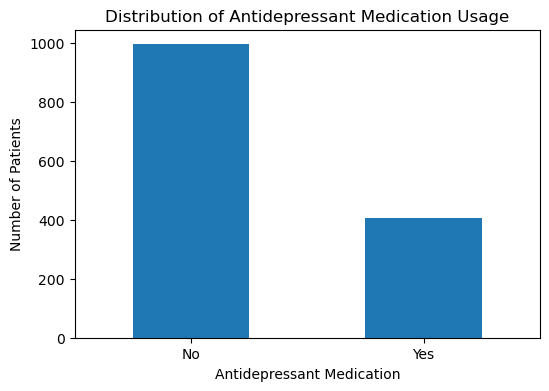

In [47]:
# For data exploration, only training data is used to avoid data leakage

# Summary statistics
print(X_train.describe())

# Men and women distribution
genderCounts = X_train['Sex'].value_counts()
plt.figure(figsize=(6,4))
genderCounts.plot(kind='bar')
plt.title('Distribution of males and females in the population')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.bar(['Male', 'Female'], genderCounts)
plt.show()

# People who are on antidepressantMedication vs not
med_counts = X_train['AntidepressantMedication'].value_counts()
plt.figure(figsize=(6,4))
med_counts.plot(kind='bar')
plt.title('Distribution of Antidepressant Medication Usage')
plt.xlabel('Antidepressant Medication')
plt.ylabel('Number of Patients')
plt.xticks(ticks=[0,1], labels=['No', 'Yes'], rotation=0)
plt.show()





## Choosing features to use

Before training I want to drop some features so that there is not so many questions on the web-application. Therefore I need to figure out which features contribute the most/are most important for the result. 

In [48]:
# Using one hot encoding for categorical variables ensures that no ordinal relationship is assumed between categories
categorical = [
    "Sex", "AgeGroup", "MaritalStatus", "Education",
    "DepressionType", "AntidepressantBeforeECT",
    "InitialSetting", "Coercion"
]

binary = [c for c in X.columns if c not in categorical]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical),
        ("bin", "passthrough", binary)
    ]
)

### Baseline model
Using logistic regression L1 Lasso for my first feature selection. This model works well with binary outcomes, which is what the regression feature is, and the dataset also contains a lot of binary features.

In [49]:
lasso_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=5000
    ))
])

lasso_model.fit(X_train, y_train)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Extracting the features from the L1 Lasso


In [50]:
feature_names = (
    lasso_model.named_steps["prep"]
    .get_feature_names_out()
)

coefs = lasso_model.named_steps["clf"].coef_[0]

selected = feature_names[np.abs(coefs) > 0]
selected

array(['cat__Sex_Male', 'cat__AgeGroup_31-40', 'cat__AgeGroup_51-60',
       'cat__AgeGroup_61-70', 'cat__AgeGroup_71-80',
       'cat__AgeGroup_81-90', 'cat__MaritalStatus_Married',
       'cat__MaritalStatus_Widowed', 'cat__Education_>12 years',
       'cat__Education_≤10 years', 'cat__DepressionType_Unipolar',
       'cat__AntidepressantBeforeECT_0-3 months before',
       'cat__AntidepressantBeforeECT_Never',
       'cat__InitialSetting_Outpatient', 'cat__Coercion_Voluntary',
       'bin__PsychoticFeatures', 'bin__SubstanceUse',
       'bin__PersonalityDisorder', 'bin__AntidepressantMedication',
       'bin__Lithium', 'bin__Lamotrigine', 'bin__Valproate',
       'bin__Benzodiazepines', 'bin__AntipsychoticMedication'],
      dtype=object)

### Second model : Random forest. 
I also want to try the random forest model, as this captures non-linear effects and can capture interactions within the features. 

In [51]:
rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    ))
])

rf.fit(X_train, y_train)

,steps,"[('prep', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
importances = rf.named_steps["rf"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
27,bin__AntipsychoticMedication,0.054721
21,bin__AnxietyDisorder,0.052350
26,bin__Benzodiazepines,0.052314
0,cat__Sex_Male,0.051165
16,cat__InitialSetting_Outpatient,0.047465
22,bin__AntidepressantMedication,0.044030
10,cat__Education_>12 years,0.043365
18,bin__PsychoticFeatures,0.043156
11,cat__Education_≤10 years,0.041670
20,bin__PersonalityDisorder,0.040562


### Permutaion importance
This is a robust, model-agnostic technique which measures a features impact on a model by shuffling the values and observing if there is a drop in the models score. If there is a drop, it means that the feature is important. Bigger drop -> more important.

In [53]:
r = permutation_importance(
    rf, X_train, y_train,
    n_repeats=30,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(10)

,feature,importance
9,AntidepressantBeforeECT,0.052969
1,AgeGroup,0.052042
2,MaritalStatus,0.037583
5,PsychoticFeatures,0.016689
3,Education,0.014843
4,DepressionType,0.009862
0,Sex,0.006186
16,Benzodiazepines,0.005293
7,PersonalityDisorder,0.005242
17,AntipsychoticMedication,0.003584


### Combining the different results to choose the features
Now that we have 3 feature selection results I can go ahead and choose which to use based on the results. 
Goal is to have around 7-8 features to use, as this is not too many questions, but it should be enough to caputre important information and get a profile on what kind of patient it is.

Based on feature selection, these features seems to have the most importance and makes sense to fill in the form on the website: 

--> Age

--> Gender

--> Tried antidepressants?

--> Depression type (Unipolar or bipolar type)

--> Benzodiazepines

--> Psychotic features

--> Personality disorder

## Model selection

- Choosing models to use, fitting to training data and validation data, choosing the best one to go further with to the test data.

Choosing to use simple models that does not take long time to train. Start with 3 models and choose which one is performing the best based on validation data. 

#### Choice of models
--> Random forest 

-->Logistic regression

-->Gradient boosting


In [54]:
selected_features = [
    "AgeGroup",
    "Sex",
    "DepressionType",
    "AntidepressantBeforeECT",
    "PsychoticFeatures",
    "PersonalityDisorder",
    "Benzodiazepines"
]

X_reduced = data[selected_features]
y = data["Remission"]

print (X_reduced.head())


  AgeGroup     Sex DepressionType AntidepressantBeforeECT  PsychoticFeatures  \
0    41-50  Female       Unipolar        0-3 months after                  0   
1    31-40    Male       Unipolar       0-3 months before                  0   
2    71-80    Male       Unipolar       0-3 months before                  0   
3    31-40    Male        Bipolar        0-3 months after                  1   
4    41-50  Female       Unipolar         ≥6 months after                  0   

   PersonalityDisorder  Benzodiazepines  
0                    0                0  
1                    0                0  
2                    0                0  
3                    0                1  
4                    1                1  


In [55]:
#Split new dataset into training, validation and testing sets 70/15/15
X_train, X_valtest, y_train, y_valtest = train_test_split(X_reduced, y, test_size=0.3, random_state=42)
# Further split validation and testing sets
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=42)

#Print shape to see if splits are correct, should be 70/15/15 and total should equal (2000, 7)
print (f"Training set size: {X_train.shape}, Validation set size: {X_val.shape}, Testing set size: {X_test.shape}")


Training set size: (1400, 7), Validation set size: (300, 7), Testing set size: (300, 7)


In [56]:
#Convert agegroup to midpoint, this will represent the age group as a value instead of a category.

def age_midpoint(age_group):
    low, high = age_group.split("-")
    return (int(low) + int(high)) / 2

X_train["AgeGroup"] = X_train["AgeGroup"].apply(age_midpoint)
X_val["AgeGroup"] = X_val["AgeGroup"].apply(age_midpoint)

## Model selection pipeline

Splitting the features into two different categories : Categorical and numeric. This is because the dataset cointains both strings and float values. Because common models cannot handle strings, it is necessary to encode them. I also decided to use a pipeline to ensure efficiency, reprodicibility and consistency.

In [57]:
categorical_cols = [
    "Sex",
    "DepressionType",
    "AntidepressantBeforeECT"
]

numeric_cols = [
    "AgeGroup",
    "PsychoticFeatures",
    "PersonalityDisorder",
    "Benzodiazepines"
]

### Random forest 
Random forest is an ensemble model which captures nonlinear relationships. It creates different decision trees and combines the prediction from the trees to create a single tree. 

### Logistic regression
Logistic regression is a linear model which captures linear relationships by examining the relationship between the features and the target variable. It is different from linear regression by predicting categorical outcome instead of continous values. Well suited in this task because we are prediciting remission or no remission. 

### Gradient boosting
Gradient boosting is a enseble model which builds a strong model by combining other weak models, training to minimize loss function. After each iteration of computing the gradient of the loss function, the weak model is added to the ensemble and a new weak model is being trained to predict the gradient until a stop criterion is met. 

In [59]:
from sklearn.model_selection import GridSearchCV


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

pipeline_rf = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(random_state=42))
])

grid_rf = {
    "rf__n_estimators": [100, 200, 500],
    "rf__max_depth": [None, 10, 20, 30],
    "rf__criterion": ["gini", "entropy"],
}

bestmodelrf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=grid_rf,
    cv=5,
    n_jobs=-1,
    scoring="roc_auc"
)

bestmodelrf.fit(X_train, y_train)

print("Best parameters for Random Forest:", bestmodelrf.best_params_)


Best parameters for Random Forest: {'rf__criterion': 'gini', 'rf__max_depth': 10, 'rf__n_estimators': 200}


### Finding out the best model
Use validation data to evaluate which model is performing the best. Avoiding underfitting and overfitting. This model is then being used on the test data, and used for the project further to evaluate new unseen data plotted into the web application.